In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

torch.random.manual_seed(42)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
learning_rate = 1e-2
batch_size = 64
epochs = 1000

device

device(type='mps')

In [189]:
df = pd.read_csv("data/salary_data.csv", dtype=np.float32)
np.save("data/salary_data.npy", df.values)

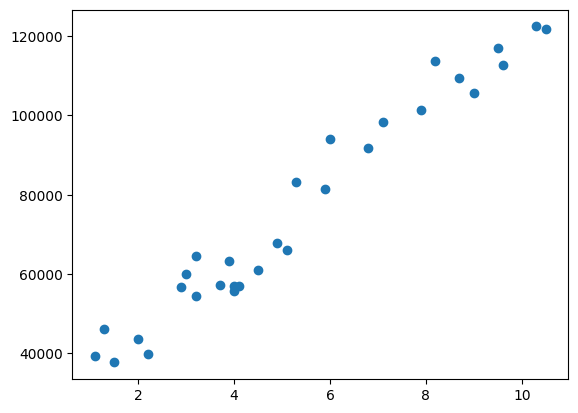

In [190]:
from torch.utils.data import Dataset, DataLoader, random_split

class CustomDataset(Dataset):
    def __init__(self):
        arr = np.load("data/salary_data.npy")
        self.data = torch.from_numpy(arr[:, 0]).float()
        self.labels = torch.from_numpy(arr[:, 1]).float()
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]
    
dataset = CustomDataset()

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

plt.scatter(df["YearsExperience"], df["Salary"])

In [191]:
import torch.nn as nn

class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(1, 10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )

    def forward(self, x):
        return self.linear(x)

model = CustomModel().to(device)

In [192]:
class RMSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_pred, y_true):
        return torch.sqrt(self.mse(y_pred, y_true) + self.eps)

loss_fn = RMSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [193]:
def train(dataloader, model, loss_fn, optimizer):
    model.train()
    sum_loss = 0
    size = len(dataloader)
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).unsqueeze(-1), y.to(device).unsqueeze(-1)
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sum_loss += loss.item()
    return sum_loss / size

def test(dataloader, model, loss_fn):
    model.eval()
    sum_loss = 0
    size = len(dataloader)
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).unsqueeze(-1), y.to(device).unsqueeze(-1)
            pred = model(X)
            loss = loss_fn(pred, y)
            sum_loss += loss.item()
    return sum_loss / size

In [194]:
for epoch in range(epochs):
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    test_loss = test(test_dataloader, model, loss_fn)
    print(f"epoch: {epoch+1}\t train_loss: {train_loss:.0f}\t test_loss: {test_loss:.0f}")

epoch: 1	 train_loss: 78952	 test_loss: 87076
epoch: 2	 train_loss: 78951	 test_loss: 87075
epoch: 3	 train_loss: 78950	 test_loss: 87074
epoch: 4	 train_loss: 78949	 test_loss: 87073
epoch: 5	 train_loss: 78948	 test_loss: 87072
epoch: 6	 train_loss: 78947	 test_loss: 87071
epoch: 7	 train_loss: 78946	 test_loss: 87069
epoch: 8	 train_loss: 78945	 test_loss: 87068
epoch: 9	 train_loss: 78943	 test_loss: 87066
epoch: 10	 train_loss: 78942	 test_loss: 87065
epoch: 11	 train_loss: 78941	 test_loss: 87063
epoch: 12	 train_loss: 78939	 test_loss: 87061
epoch: 13	 train_loss: 78937	 test_loss: 87059
epoch: 14	 train_loss: 78935	 test_loss: 87057
epoch: 15	 train_loss: 78933	 test_loss: 87054
epoch: 16	 train_loss: 78931	 test_loss: 87052
epoch: 17	 train_loss: 78928	 test_loss: 87049
epoch: 18	 train_loss: 78925	 test_loss: 87045
epoch: 19	 train_loss: 78922	 test_loss: 87041
epoch: 20	 train_loss: 78919	 test_loss: 87037
epoch: 21	 train_loss: 78915	 test_loss: 87032
epoch: 22	 train_loss:

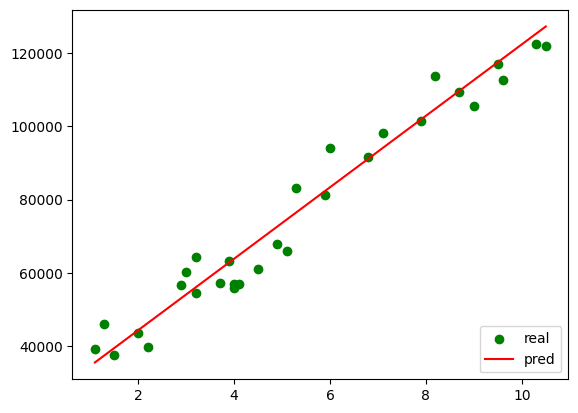

In [195]:
model.eval()
pred = model(torch.tensor(df["YearsExperience"]).to(device).float().unsqueeze(-1))
plt.scatter(df["YearsExperience"], df["Salary"], c='g', label='real')
plt.plot(df["YearsExperience"], pred.cpu().detach().numpy(), c='r', label='pred')
plt.legend(loc=4)
plt.show()